## Overview of gradient descent (J)

Conceito fundamental para deep learning. Fazemos uma análise para obter o mínimo global da função que relaciona os pesos com o gradiente de descida.
 - iniciamos com a estimative de um mínimo de uma função f.
 - computamos a derivada com o ponto de mínimo chutado.
 - realizamos novas iterações para obter uma taxa de aprendizado.
 - Não é garantido que o gradiente de descida dê uma solução correta, há erros.

## What about local minima?

Há problemas de usar o gradiente de descida:
- Verificar se a função está descendo não indica que vamos encontrar um mín;
- Podem haver mínimos locais e não global, indicando respostas erradas;
- Para dimensões maiores que 2, fica impossível visualizar mínimos globais, ou seja não é tão direto como em uma dimensão;
- Para inúmeras dimensões, os pontos de mínimo local em uma dimensão não são necessariamente mínimo para as outras dimensões.
- Podemos então treinar o modelo com diferentes pesos iniciais, assim ele começa em pontos diferentes e vai ajustando a cada geração.
- Podemos também aumentar a dimensionalidade do problema (tornando mais complexo), porém com menores mínimos locais.

## Gradient descent in 1D

Parâmetros importantes: taxa de aprendizado (learning rate) e número de épocas (training epochs).

In [3]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

from matplotlib_inline.backend_inline import set_matplotlib_formats
# Define o formato global para SVG
set_matplotlib_formats('svg')

In [5]:
# function (as a function)
def fx(x):
    return 3*x**2 - 3*x + 4

# your derivative
def deriv(x):
    return 6*x - 3

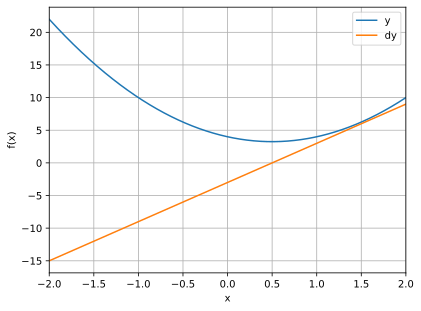

In [7]:
# plot the function and its derivative

# define a range for x
x = np.linspace(-2,2,2001)

# plotting
plt.plot(x,fx(x),x,deriv(x))
plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['y','dy'])
plt.show()

In [ ]:
# random starting point
localmin = np.random.choice(x,1) # um valor aleatório

print('antes:',localmin)

# learning parameters
learning_rate = .01
training_epochs = 100

# run throught training - implementamos o algoritmo de gradiente de descida.
for i in range(training_epochs):
    grad = deriv(localmin)
    localmin = localmin - learning_rate*grad

print('depois:',localmin)

antes: [-1.746]
depois: [0.49538475]


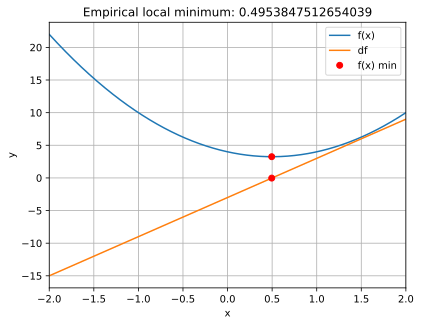

In [68]:
# plot the results

plt.plot(x,fx(x),x,deriv(x))
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Empirical local minimum: %s' %localmin[0])
plt.show()


In [181]:
# Store the model parameters and outputs on each iteration

# random starting point
localmin = np.random.choice(x,1)

# learning parameters
learning_rate = 0.01
training_epochs = 100

# run throught training and store all the result
modelparams = np.zeros((training_epochs,2))
for i in range(training_epochs):
    grad = deriv(localmin)
    localmin = localmin - learning_rate*grad
    modelparams[i,0] = localmin[0]
    modelparams[i,1] = grad[0]
    # armazeno as estimativas de mínimo local e do gradiente

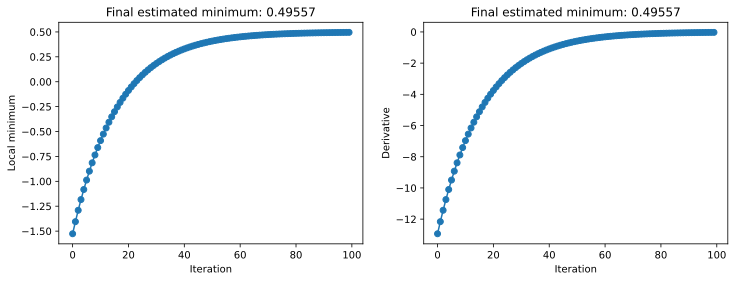

In [182]:
# plot the gradient over iterations

fig,ax = plt.subplots(1,2,figsize=(12,4))

for i in range(2):
    ax[i].plot(modelparams[:,i],'o-')
    ax[i].set_xlabel('Iteration')
    ax[i].set_title(f'Final estimated minimum: {localmin[0]:.5f}')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')
plt.show()

# eu consigo ver que conforme as épocas foi se aproximando do valor real do mínimo.

## Additional exploration

1) Most often in DL, the model trains for a set number of iterations, which is what we do here. But there are other ways
   of defining how long the training lasts. Modify the code so that training ends when the derivative is smaller than
   some threshold, e.g., 0.1. Make sure your code is robust for negative derivatives.

2) Does this change to the code produce a more accurate result? What if you change the stopping threshold?

3) Can you think of any potential problems that might arise when the stopping criterion is based on the derivative
   instead of a specified number of training epochs?

---

De maneira geral, quando tentamos usar um limiar fixo podemos ter alguns problemas, pois o aprendizado é cortado e não necessariamente estamos próximos do valor correto (considera apenas grad < 0.1, por exemplo).

O resultado será mais impreciso, a não ser que seja considerado limiares variáveis que refletem essa aproximação entre localmin e de fato o mínimo local obtido por df/dx=0. Porém não faria sentido usar um processo de iterações se eu já tenho o resultado matemático. Além disso, em $R^n$ isso seria extremamente complexo...

## CodeChallenge: unfortunate starting value

Desafio sobre o gradiente de descida. Precisamos repetir o processo e encontrar o mínimo da seguinte função:
$$
f(x) = cos(2\pi x) + x^2, \;\; x \in {-2,2}
$$

Queremos codificar o valor final x=0 (não vamos usar o np.random.choice(x,1), mas sim x = 0).

In [363]:
# defino as funções, computando a função e sua derivada

def fx(x):
    return np.cos(2*np.pi*x)+x**2

def deriv(x):
    return -2*np.pi*np.sin(2*np.pi*x)+2*x

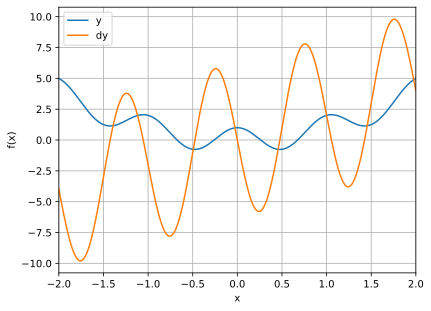

In [364]:
x = np.linspace(-2,2,2001)

# plotting
plt.plot(x,fx(x),x,deriv(x))
plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['y','dy'])
plt.show()

In [365]:
# definir a array x=0, é importante notar que nesse caso a df/dx=0 pode nos dar x=0, x~+/-0.48
# precisamos saber filtrar que em x=0 a função apresenta um máximo local.

# defino a taxa de aprendizado e temporadas
learning_rate = 0.01
training_epochs = 100

modelparams = np.zeros((training_epochs,2)) # localmin1 = np.array([0])
result = np.array([])

for j in range(training_epochs):
    localmin = np.random.choice(x,1)
    for i in range(training_epochs):
        # confirmando se é um mínimo local, código para mínimo negativo
        if (fx(localmin+learning_rate) - fx(localmin)) > 0:
            grad = deriv(localmin)
            localmin = localmin - learning_rate*grad
            modelparams[i,0] = localmin[0]
            modelparams[i,1] = grad[0]
        else:
            localmin = localmin-learning_rate
            i = 0

        if (fx(localmin-learning_rate) - fx(localmin)) > 0:
            grad = deriv(localmin)
            localmin = localmin - learning_rate*grad
            modelparams[i,0] = localmin[0]
            modelparams[i,1] = grad[0]
        else:
            localmin = localmin+learning_rate
            i = 0

    result = np.append(result,localmin)


# nesse código eu forço o aprendizado, fazendo com que o mínimo local sofra desvios, caso o valor inicial seja nulo.
# isso impede que ocorra o gradiente de desaparecimento, onde o learning_rate*grad sempre é nulo.

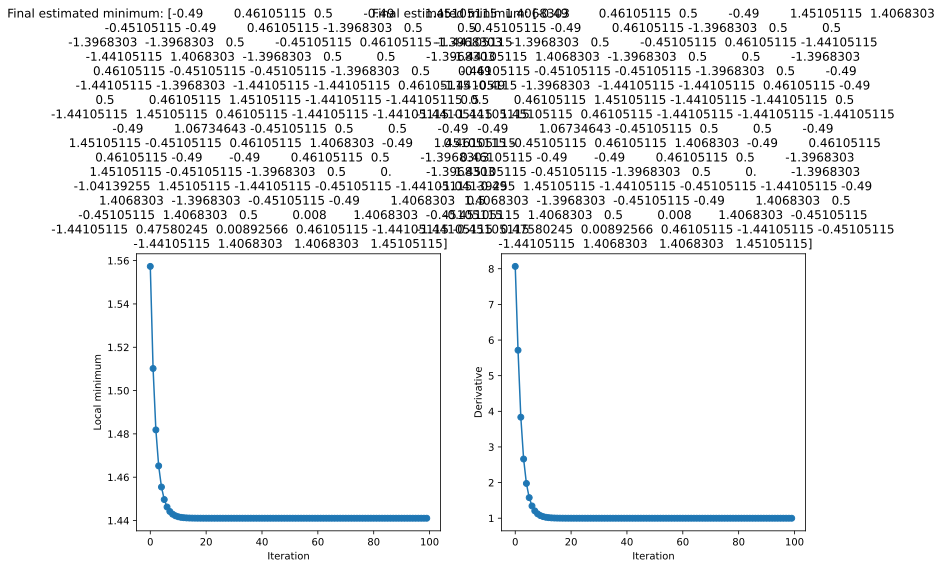

In [366]:
# apresentar os gráficos

fig,ax = plt.subplots(1,2,figsize=(12,5))

for i in range(2):
    ax[i].plot(modelparams[:,i],'o-')
    ax[i].set_xlabel('Iteration')
    ax[i].set_title(f'Final estimated minimum: {result}')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')
plt.show()

# eu consigo ver que conforme as épocas foi se aproximando do valor real do mínimo.

1) A derivada contém um fator multiplicativo igual a 2. Essa constante é necessária para a precisão do resultado do gradiente descendente? 
Tente remover esse "2" da derivada e verifique se o modelo ainda consegue encontrar o mínimo. Antes de executar o
código, reflita sobre o que você espera que aconteça. A realidade corresponde às suas expectativas? Por que esse fator é (ou não é) necessário?

2) E quanto ao fator "2" dentro da função `np.sin()`? Ele é importante? É possível obter um resultado preciso se você
o remover?

3) Tente definir o valor inicial como um número pequeno, porém diferente de zero (por exemplo, 0,0001 ou -0,0001). Isso ajuda na solução?

---
A constante 2 na derivada não influencia para encontrar os mínimos, já que quando igualamos a zero, ela basicamente é cancelada. Na função f e df só vai variar o fator de escala.

Agora o 2 na função seno não pode ser retirado, pois mudaríamos a posição dos picos.

Definindo um valor inicial tendendo a zero, o modelo consegue uma solução, pois isso é suficiente para o aprendizado.
